# Lecture 5: Model evaluation

In [1]:
import polars as pl, numpy as np
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.neighbors import KNeighborsRegressor
import sklearn
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# `train_test_split`

In [2]:
from sklearn.model_selection import train_test_split

In [3]:
X, y = np.arange(10).reshape((5, 2)), np.arange(5)

In [4]:
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=2, random_state=2)

In [5]:
Xtrain, ytrain

(array([[2, 3],
        [6, 7],
        [0, 1]]),
 array([1, 3, 0]))

In [6]:
Xtest, ytest

(array([[4, 5],
        [8, 9]]),
 array([2, 4]))

## Workflow with real data

In [7]:
df = (
    pl.read_csv("https://github.com/Michael-tehc/MachineLearning-MSU/raw/refs/heads/main/data/Housing.csv")
    .with_columns(
        pl.col('price', 'area').log(),
        pl.col('mainroad guestroom basement'.split()).replace_strict({
            'yes': 1, 'no': 0
        })
    )
)
df

price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
f64,f64,i64,i64,i64,i64,i64,i64,str,str,i64,str,str
16.403275,8.911934,4,2,3,1,0,0,"""no""","""yes""",2,"""yes""","""furnished"""
16.321036,9.100526,4,4,4,1,0,0,"""no""","""yes""",3,"""no""","""furnished"""
16.321036,9.206332,3,2,2,1,0,1,"""no""","""no""",2,"""yes""","""semi-furnished"""
16.318175,8.922658,4,2,2,1,0,1,"""no""","""yes""",3,"""yes""","""furnished"""
16.250001,8.911934,4,1,2,1,1,1,"""no""","""yes""",2,"""no""","""furnished"""
…,…,…,…,…,…,…,…,…,…,…,…,…
14.414347,8.006368,2,1,1,1,0,1,"""no""","""no""",2,"""no""","""unfurnished"""
14.384879,7.783224,3,1,1,0,0,0,"""no""","""no""",0,"""no""","""semi-furnished"""
14.375126,8.194229,2,1,1,1,0,0,"""no""","""no""",0,"""no""","""unfurnished"""


In [8]:
X, y = (
    df.select('area bedrooms bathrooms stories mainroad guestroom'.split()).to_numpy(),
    df['price'].to_numpy()
)

In [9]:
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=2, random_state=2)
# Fit on training split
model = Ridge().fit(Xtrain, ytrain)
# Compute validation loss
mean_squared_error(
    ytest, model.predict(Xtest)
)

0.13556360779841

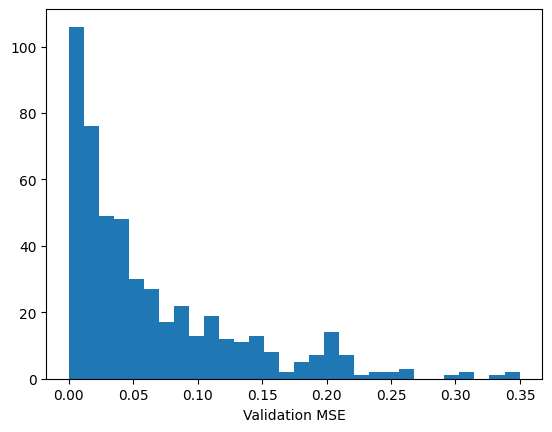

In [10]:
# What do losses look like for random splits?
losses = []
for _ in range(500):
    Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=2)
    losses.append(
        mean_squared_error(
            ytest, Ridge().fit(Xtrain, ytrain).predict(Xtest)
        )
    )
plt.hist(losses, bins=30); plt.xlabel('Validation MSE');

# Cross-validation

- List of available scorers: https://scikit-learn.org/stable/modules/model_evaluation.html#scoring-string-names

In [11]:
from sklearn.model_selection import KFold, cross_val_score

In [12]:
for (i, (train_idx, test_idx)) in enumerate(KFold(4).split(X)):
    print("Fold:", i)
    print(f"\t{train_idx=}")

Fold: 0
	train_idx=array([137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149,
       150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162,
       163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175,
       176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188,
       189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201,
       202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214,
       215, 216, 217, 218, 219, 220, 221, 222, 223, 224, 225, 226, 227,
       228, 229, 230, 231, 232, 233, 234, 235, 236, 237, 238, 239, 240,
       241, 242, 243, 244, 245, 246, 247, 248, 249, 250, 251, 252, 253,
       254, 255, 256, 257, 258, 259, 260, 261, 262, 263, 264, 265, 266,
       267, 268, 269, 270, 271, 272, 273, 274, 275, 276, 277, 278, 279,
       280, 281, 282, 283, 284, 285, 286, 287, 288, 289, 290, 291, 292,
       293, 294, 295, 296, 297, 298, 299, 300, 301, 302, 303, 304, 305,
       306, 307, 308, 309, 310, 311, 312, 313

In [13]:
# Manual cross_val_score
for (i, (train_idx, test_idx)) in enumerate(KFold(4).split(X)):
    Xtrain, ytrain = X[train_idx, :], y[train_idx]
    Xtest, ytest = X[test_idx, :], y[test_idx]
    model = Ridge().fit(Xtrain, ytrain)
    yhat = model.predict(Xtest)
    loss = mean_squared_error(ytest, yhat)
    print(f"Fold: {i}, MSE: {loss:.8f}")

Fold: 0, MSE: 0.16612568
Fold: 1, MSE: 0.04355568
Fold: 2, MSE: 0.03296525
Fold: 3, MSE: 0.16053967


In [14]:
scores_cv = cross_val_score(
    Ridge(), X, y,
    cv=KFold(4),
    # "score" means "higher is better"
    scoring='neg_mean_squared_error'
); scores_cv

array([-0.16612568, -0.04355568, -0.03296525, -0.16053967])

In [15]:
np.quantile(-scores_cv, [0.05/2, 1-0.05/2])

array([0.03375953, 0.16570673])

## Scale-then-validate may inflate performance

In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [17]:
X, y = sklearn.datasets.make_regression(500, 5, noise=1, random_state=5)
# Introduce very few outliers
X[-5:, 0] *= 100
X[-5:, 1] *= -50

In [18]:
# BAD: scale everything, then split
scaler_bad = StandardScaler().fit(X) # Learns from entire dataset
Xscaled_bad = scaler_bad.transform(X) # Transforms EVERYTHING
Xtrain_bad, Xtest_bad, ytrain_bad, ytest_bad = train_test_split(
    Xscaled_bad, y, random_state=42
)

In [19]:
mean_squared_error(
    ytest_bad, Ridge(1).fit(Xtrain_bad, ytrain_bad).predict(Xtest_bad)
)

5590.7477936217565

In [20]:
# GOOD: split first, then scale (same random state!)
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, random_state=42)
scaler = StandardScaler().fit(Xtrain)
Xtrain, Xtest = scaler.transform(Xtrain), scaler.transform(Xtest)
# Compute validation error
mean_squared_error(
    ytest, Ridge(1).fit(Xtrain, ytrain).predict(Xtest)
)

5606.488504740486

Maybe that's just a fluke? Let's run CV.

In [21]:
def cv_bad(model, X, y, scaler, folds=5):
    X = scaler.fit_transform(X)
    MSEs = -cross_val_score(
        model, X, y, scoring='neg_mean_squared_error', cv=folds
    )
    return MSEs

In [22]:
def cv_good(pipeline, X, y, folds=5):
    MSEs = -cross_val_score(
        pipeline, X, y, scoring='neg_mean_squared_error', cv=folds
    )
    return MSEs

In [23]:
cv_splitter = KFold(10, shuffle=True, random_state=3)
cv_bad(
    Ridge(5), X, y, StandardScaler(),
    folds=cv_splitter
).mean()

np.float64(5132.428069525205)

In [24]:
cv_good(
    Pipeline([
        ('scaler', StandardScaler()),
        ('regression', Ridge(5))
    ]), X, y,
    folds=cv_splitter
).mean()

np.float64(5153.103264795066)

## Hyperparameter selection

This is actually "brute-force" optimization of the validation loss.

In [25]:
X, y = sklearn.datasets.make_regression(500, 5, noise=1, random_state=5)
X[-1, :] *= 100 # outlier

In [26]:
from itertools import product

In [27]:
def gen_product(grid: dict[str, ...]):
    kv_ordered = list(grid.items())
    keys_ordered = [key for key, value in kv_ordered]
    values_ordered = [value for key, value in kv_ordered]
    for values_perm in product(*values_ordered):
        yield {key: value for key, value in zip(keys_ordered, values_perm)}

for perm in gen_product({'x': [1,2], 'y': [6,7]}):
    print(perm)

{'x': 1, 'y': 6}
{'x': 1, 'y': 7}
{'x': 2, 'y': 6}
{'x': 2, 'y': 7}


In [28]:
model = Ridge(alpha=5)
model_changed = model.set_params(alpha=100)
model.alpha, model_changed.alpha

(100, 100)

In [29]:
class MyGridSearchCV:
    def __init__(self, model, grid: dict[str, ...], cv: int=5):
        self.model = model
        self.grid = grid
        self.cv = cv
        self.best_score_ = -np.inf
        self.best_params_ = None

    def __repr__(self):
        return (
            f"{self.__class__.__name__}:\n"
            f"\t{self.best_score_=:.5f}\n"
            f"\t{self.best_params_=}"
        )

    def fit(self, X, y):
        mean_scores = []
        for perm in gen_product(self.grid):
            model.set_params(**perm)
            scores = cross_val_score(
                model, X, y, scoring='neg_mean_squared_error', cv=self.cv
            )
            mean_scores.append(
                (scores.mean(), perm)
            )
        score_highest, perm_best = max(mean_scores, key=lambda obj: obj[0])
        self.cv_results_ = mean_scores
        self.best_score_ = score_highest
        self.best_params_ = perm_best
        return self

In [30]:
MyGridSearchCV(
    Ridge(), # model
    {'alpha': np.logspace(-5, 1, 100)}, # parameter space
).fit(X, y)

MyGridSearchCV:
	self.best_score_=-2337317.49415
	self.best_params_={'alpha': np.float64(10.0)}

In [31]:
from sklearn.model_selection import GridSearchCV

In [32]:
gs = GridSearchCV(
    Ridge(), # model
    {'alpha': np.logspace(-5, 1, 100)}, # parameter space
    scoring='neg_mean_squared_error'
).fit(X, y)
print('Best score :', gs.best_score_)
print('Best params:', gs.best_params_)

Best score : -2337317.4941504113
Best params: {'alpha': np.float64(10.0)}


# Overfitting

Fit high-degree polynomials to force obvious overfitting.

In [33]:
def my_make_regression(f, n_samples: int, bias=0.0, scale=0.2, random_state=None):
    rng = np.random.RandomState(random_state)
    X = rng.uniform(0, 1, size=(n_samples, 1))
    noise = rng.normal(size=(n_samples, 1))
    
    y = bias + f(X) + scale * noise
    return X, y

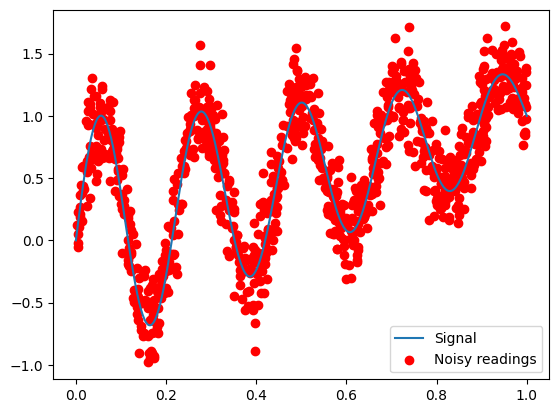

In [34]:
fun = lambda x: np.sin(9 * np.pi * x) * np.exp(-x) + x
X, y = my_make_regression(fun, 1000, random_state=43)
assert X.shape == (len(y), 1)

xs = np.linspace(0, 1, 500)
plt.plot(xs, fun(xs), label="Signal")
plt.scatter(X[:, 0], y, label="Noisy readings", c='red'); plt.legend();

In [35]:
Xtrain, Xval, ytrain, yval = train_test_split(X, y, train_size=0.3)

## How to build polynomial features?

Transform initial 1D data:
$$
\begin{bmatrix}
x_1\\
x_2\\
x_3\\
\vdots\\
x_N
\end{bmatrix}
\implies
\begin{bmatrix}
x_1^0 & x_1^1 & x_1^2 & x_1^3 & \dots\\
x_2^0 & x_2^1 & x_2^2 & x_2^3 & \dots\\
x_3^0 & x_3^1 & x_3^2 & x_3^3 & \dots\\
\vdots & \vdots & \vdots & \vdots & \ddots\\
x_N^0 & x_N^1 & x_N^2 & x_N^3 & \dots\\
\end{bmatrix}
$$

- Rows: observations.
- Columns: powers of observations.

This is called the [Vandermonde matrix](https://en.wikipedia.org/wiki/Vandermonde_matrix). NumPy has [`np.vander`](https://numpy.org/doc/stable/reference/generated/numpy.vander.html).

In [36]:
np.vander([0,1,2,3], N=5, increasing=True)

array([[ 1,  0,  0,  0,  0],
       [ 1,  1,  1,  1,  1],
       [ 1,  2,  4,  8, 16],
       [ 1,  3,  9, 27, 81]])

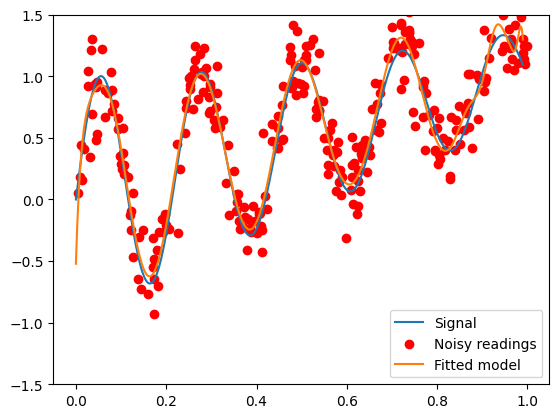

In [37]:
DEGREE = 100
Xtrain_poly = np.vander(Xtrain[:, 0], DEGREE, increasing=True)
Xval_poly = np.vander(Xval[:, 0], DEGREE, increasing=True)
# NOTE: the Vandermonde matrix covers the entire basis,
# so the intercept is included in the data!
model = LinearRegression(fit_intercept=False).fit(Xtrain_poly, ytrain)

xs = np.linspace(0, 0.99, 1000)
xs_poly = np.vander(xs, DEGREE, increasing=True) # to feed into the model

plt.plot(xs, fun(xs), label="Signal")
plt.scatter(Xtrain[:, 0], ytrain, label="Noisy readings", c='red');
plt.plot(xs, model.predict(xs_poly), label="Fitted model")
plt.ylim(-1.5, 1.5)
plt.legend();

In [38]:
mean_squared_error(
    yval, model.predict(Xval_poly)
)

0.043968580743553067

## Overfitting with high degrees

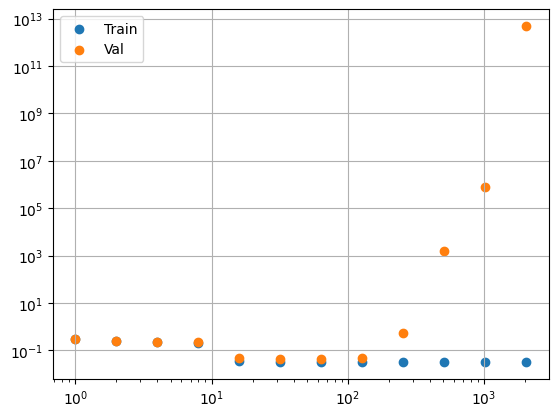

In [39]:
degrees = [1,2,4,8,16,32,64,128,256,512,1024,2048]
MSEs_train, MSEs_val = [], []
for deg in degrees:
    Xtrain_poly = np.vander(Xtrain[:, 0], deg, increasing=True)
    Xval_poly = np.vander(Xval[:, 0], deg, increasing=True)
    model = LinearRegression(fit_intercept=False).fit(Xtrain_poly, ytrain)
    MSEs_train.append(
        mean_squared_error(ytrain, model.predict(Xtrain_poly))
    )
    MSEs_val.append(
        mean_squared_error(yval, model.predict(Xval_poly))
    )
plt.scatter(degrees, MSEs_train, label="Train")
plt.scatter(degrees, MSEs_val, label="Val")
plt.xscale('log'); plt.yscale('log')
plt.grid(); plt.legend();

# Bonus: Bernstein basis to easily control high-degree polynomials

Based on: https://alexshtf.github.io/2024/01/21/Bernstein.html.

In [40]:
import warnings; warnings.simplefilter("ignore", UserWarning)

In [41]:
DEGREE = 5

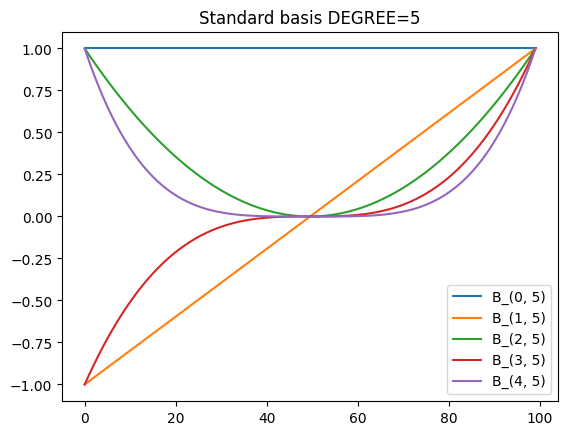

In [42]:
xs = np.linspace(-1, 1, 100)
Y = np.vander(xs, DEGREE, increasing=True)
for b in range(Y.shape[1]):
    plt.plot(Y[:, b], label=f"B_({b}, {DEGREE})")
plt.title(f"Standard basis {DEGREE=}")
plt.legend();

In [43]:
import joblib

In [44]:
from scipy.stats import binom

def bernvander(x, n: int):
    x = np.array(x)
    assert x.ndim == 1
    return binom.pmf(np.arange(1 + n), n, x[:, None])

In [45]:
bernvander([.1,.2,.3], DEGREE)

array([[5.9049e-01, 3.2805e-01, 7.2900e-02, 8.1000e-03, 4.5000e-04,
        1.0000e-05],
       [3.2768e-01, 4.0960e-01, 2.0480e-01, 5.1200e-02, 6.4000e-03,
        3.2000e-04],
       [1.6807e-01, 3.6015e-01, 3.0870e-01, 1.3230e-01, 2.8350e-02,
        2.4300e-03]])

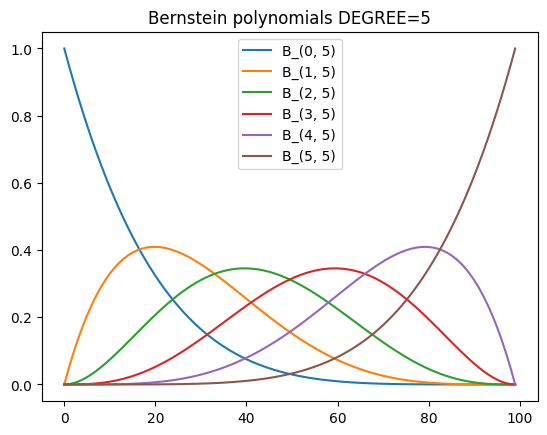

In [46]:
xs = np.linspace(0, 1, 100)
Y = bernvander(xs, DEGREE)
for b in range(Y.shape[1]):
    plt.plot(Y[:, b], label=f"B_({b}, {DEGREE})")
plt.title(f"Bernstein polynomials {DEGREE=}")
plt.legend();

In [47]:
class RidgeStandard:
    def __init__(self, n: int, lmb: float=0.0):
        self.n, self.lmb = n, lmb

    def vander(self, X):
        return np.hstack([
            np.vander(X[:, f], self.n, increasing=True)
            for f in range(X.shape[1])
        ])

    def fit(self, X, y):
        self.model_ = Ridge(self.lmb, fit_intercept=False).fit(self.vander(X), y)
        return self

    def predict(self, X):
        return self.model_.predict(self.vander(X))

In [48]:
class RidgeBernstein:
    def __init__(self, n: int, lmb: float=0.0):
        self.n, self.lmb = n, lmb

    def vander(self, X):
        return np.hstack([
            bernvander(X[:, f], self.n)
            for f in range(X.shape[1])
        ])

    def fit(self, X, y):
        self.model_ = Ridge(self.lmb, fit_intercept=False).fit(self.vander(X), y)
        return self

    def predict(self, X):
        return self.model_.predict(self.vander(X))

In [49]:
X.shape, y.shape

((1000, 1), (1000, 1))

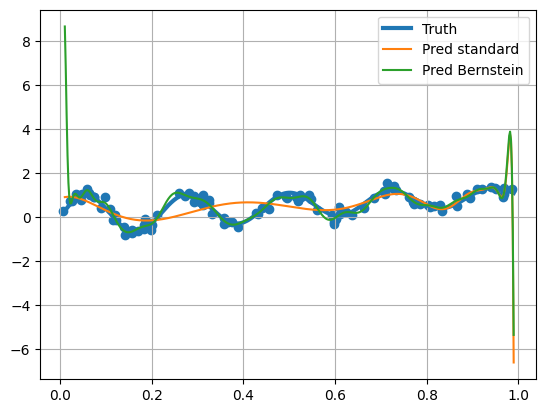

In [50]:
fun = lambda x: np.sin(9 * np.pi * x) * np.exp(-x) + x
X, y = my_make_regression(fun, 100, random_state=42)
standard = RidgeStandard(128, 1e-8).fit(X, y)
bernstein = RidgeBernstein(128, 1e-8).fit(X, y)

xs = np.linspace(0.01, 0.99, 500)
plt.plot(xs, fun(xs), linewidth=3, label='Truth')
plt.plot(xs, standard.predict(xs[:, None]), label="Pred standard")
plt.plot(xs, bernstein.predict(xs[:, None]), label="Pred Bernstein")
plt.scatter(X[:, 0], y)
plt.legend(); plt.grid();

In [51]:
def est_MSE(model, Xtrain, ytrain, Xval, yval):
    yhat = model.fit(Xtrain, ytrain).predict(Xval)
    return mean_squared_error(yval, yhat)

In [52]:
TRAIN_SIZE = 500
X, y = my_make_regression(fun, TRAIN_SIZE + 20_000, random_state=42)
Xtrain, ytrain = X[:TRAIN_SIZE, :], y[:TRAIN_SIZE]
Xval, yval = X[TRAIN_SIZE:, :], y[TRAIN_SIZE:]

CPU times: user 933 ms, sys: 226 ms, total: 1.16 s
Wall time: 6.61 s


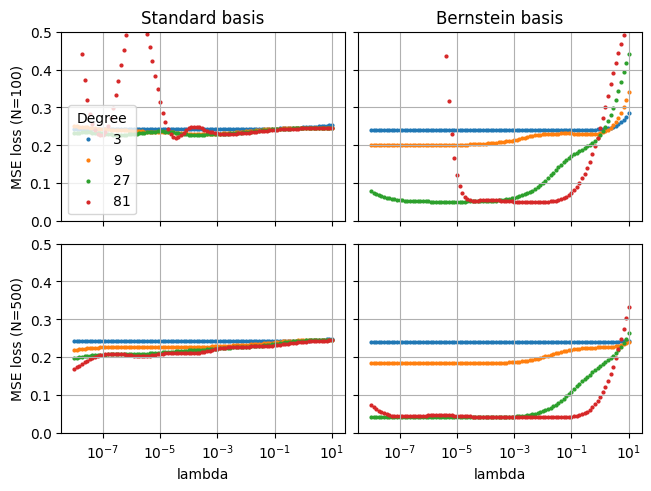

In [53]:
%%time
lambdas = np.logspace(-8, 1, 100)
f, axs = plt.subplots(nrows=2, ncols=2, sharex=True, sharey=True, layout='constrained')
axs[0,0].set_title('Standard basis')
axs[0,1].set_title('Bernstein basis')

degrees = [3**i for i in [1,2,3,4]]
for i, nobs in enumerate([100, 500]):
    axs[i,0].set_ylabel(f'MSE loss (N={nobs})')
    for j, n in enumerate(degrees):
        MSEs = np.array(joblib.Parallel(-1, timeout=1000)(
            joblib.delayed(est_MSE)(RidgeStandard(n, lmb), Xtrain[:nobs, :], ytrain[:nobs], Xval, yval)
            for lmb in lambdas
        ))
        axs[i,0].scatter(lambdas, MSEs, label=f"{n}", s=4)
        MSEs = np.array(joblib.Parallel(-1, timeout=1000)(
            joblib.delayed(est_MSE)(RidgeBernstein(n, lmb), Xtrain[:nobs, :], ytrain[:nobs], Xval, yval)
            for lmb in lambdas
        ))
        axs[i,1].scatter(lambdas, MSEs, label=f"{n}", s=4)
for ax in axs.flat:
    ax.set_ylim(0, 0.5)
    ax.set_xscale('log'); ax.grid()
axs[0,0].legend(title="Degree")
axs[-1, 0].set_xlabel('lambda')
axs[-1, 1].set_xlabel('lambda')
f;